In [ ]:
# Understand the data you are working with: Are there missing values? 
# Can they be recovered or filled easily? Can you integrate external data(e.g., hierarchical GeoHash, UberH3, or GoogleS2 encodings for spatial data) with reasonable effort?
# Can you derive additional information from the provided data (for example, from textual fields)?
# For this assignment, you can use any software/package you want

In [ ]:
import json
import csv

In [ ]:
# Load JSON data from a file
with open('tracks.json', 'r', encoding='utf-8') as json_file:
    data = json.load(json_file)

# Ensure it's a list of records
if isinstance(data, dict):
    
    data = [data]

# Write to CSV
with open('output.csv', 'w', newline='', encoding='utf-8') as csv_file:
    writer = csv.DictWriter(csv_file, fieldnames=data[0].keys())
    writer.writeheader()
    writer.writerows(data)

print("Conversion complete. CSV file saved as 'output.csv'.")

In [ ]:
import xml.etree.ElementTree as ET
import csv

# Load and parse the XML file
tree = ET.parse('artists.xml')
root = tree.getroot()

# Extract all rows
rows = root.findall('row')

# Get all unique tags from the first row (assuming all rows have same structure)
headers = [elem.tag for elem in rows[0]]

# Write to CSV
with open('output2.csv', 'w', newline='', encoding='utf-8') as f:
    writer = csv.writer(f)
    writer.writerow(headers)  # write header

    for row in rows:
        writer.writerow([row.find(tag).text if row.find(tag) is not None else '' for tag in headers])

print("XML data has been successfully converted to output2.csv.")

In [1]:
import pandas as pd
import numpy as np
df_tracks = pd.read_csv('output.csv')
df_artists = pd.read_csv('output2.csv')

In [2]:
#Are there any missing value?
print("df_tracks:",df_tracks.shape)
print("df_artists:", df_artists.shape)

df_tracks: (11166, 37)
df_artists: (104, 14)


In [3]:
print("df_tracks:", df_tracks.columns)
print("df_artists:", df_artists.columns)

df_tracks: Index(['id', 'id_artist', 'title', 'featured_artists', 'primary_artist',
       'language', 'album', 'swear_IT', 'swear_EN', 'swear_IT_words',
       'swear_EN_words', 'year', 'month', 'day', 'n_sentences', 'n_tokens',
       'char_per_tok', 'avg_token_per_clause', 'bpm', 'rolloff', 'flux', 'rms',
       'flatness', 'spectral_complexity', 'pitch', 'loudness', 'album_name',
       'album_release_date', 'album_type', 'disc_number', 'track_number',
       'duration_ms', 'explicit', 'popularity', 'id_album', 'lyrics',
       'streams@1month'],
      dtype='object')
df_artists: Index(['id_author', 'name', 'gender', 'birth_date', 'birth_place',
       'nationality', 'description', 'active_start', 'active_end', 'province',
       'region', 'country', 'latitude', 'longitude'],
      dtype='object')


In [4]:
df_tracks.dtypes

id                       object
id_artist                object
title                    object
featured_artists         object
primary_artist           object
language                 object
album                    object
swear_IT                  int64
swear_EN                  int64
swear_IT_words           object
swear_EN_words           object
year                    float64
month                   float64
day                     float64
n_sentences             float64
n_tokens                float64
char_per_tok            float64
avg_token_per_clause    float64
bpm                     float64
rolloff                 float64
flux                    float64
rms                     float64
flatness                float64
spectral_complexity     float64
pitch                   float64
loudness                float64
album_name               object
album_release_date       object
album_type               object
disc_number             float64
track_number            float64
duration

In [5]:
df_artists.dtypes

id_author        object
name             object
gender           object
birth_date       object
birth_place      object
nationality      object
description      object
active_start     object
active_end      float64
province         object
region           object
country          object
latitude        float64
longitude       float64
dtype: object

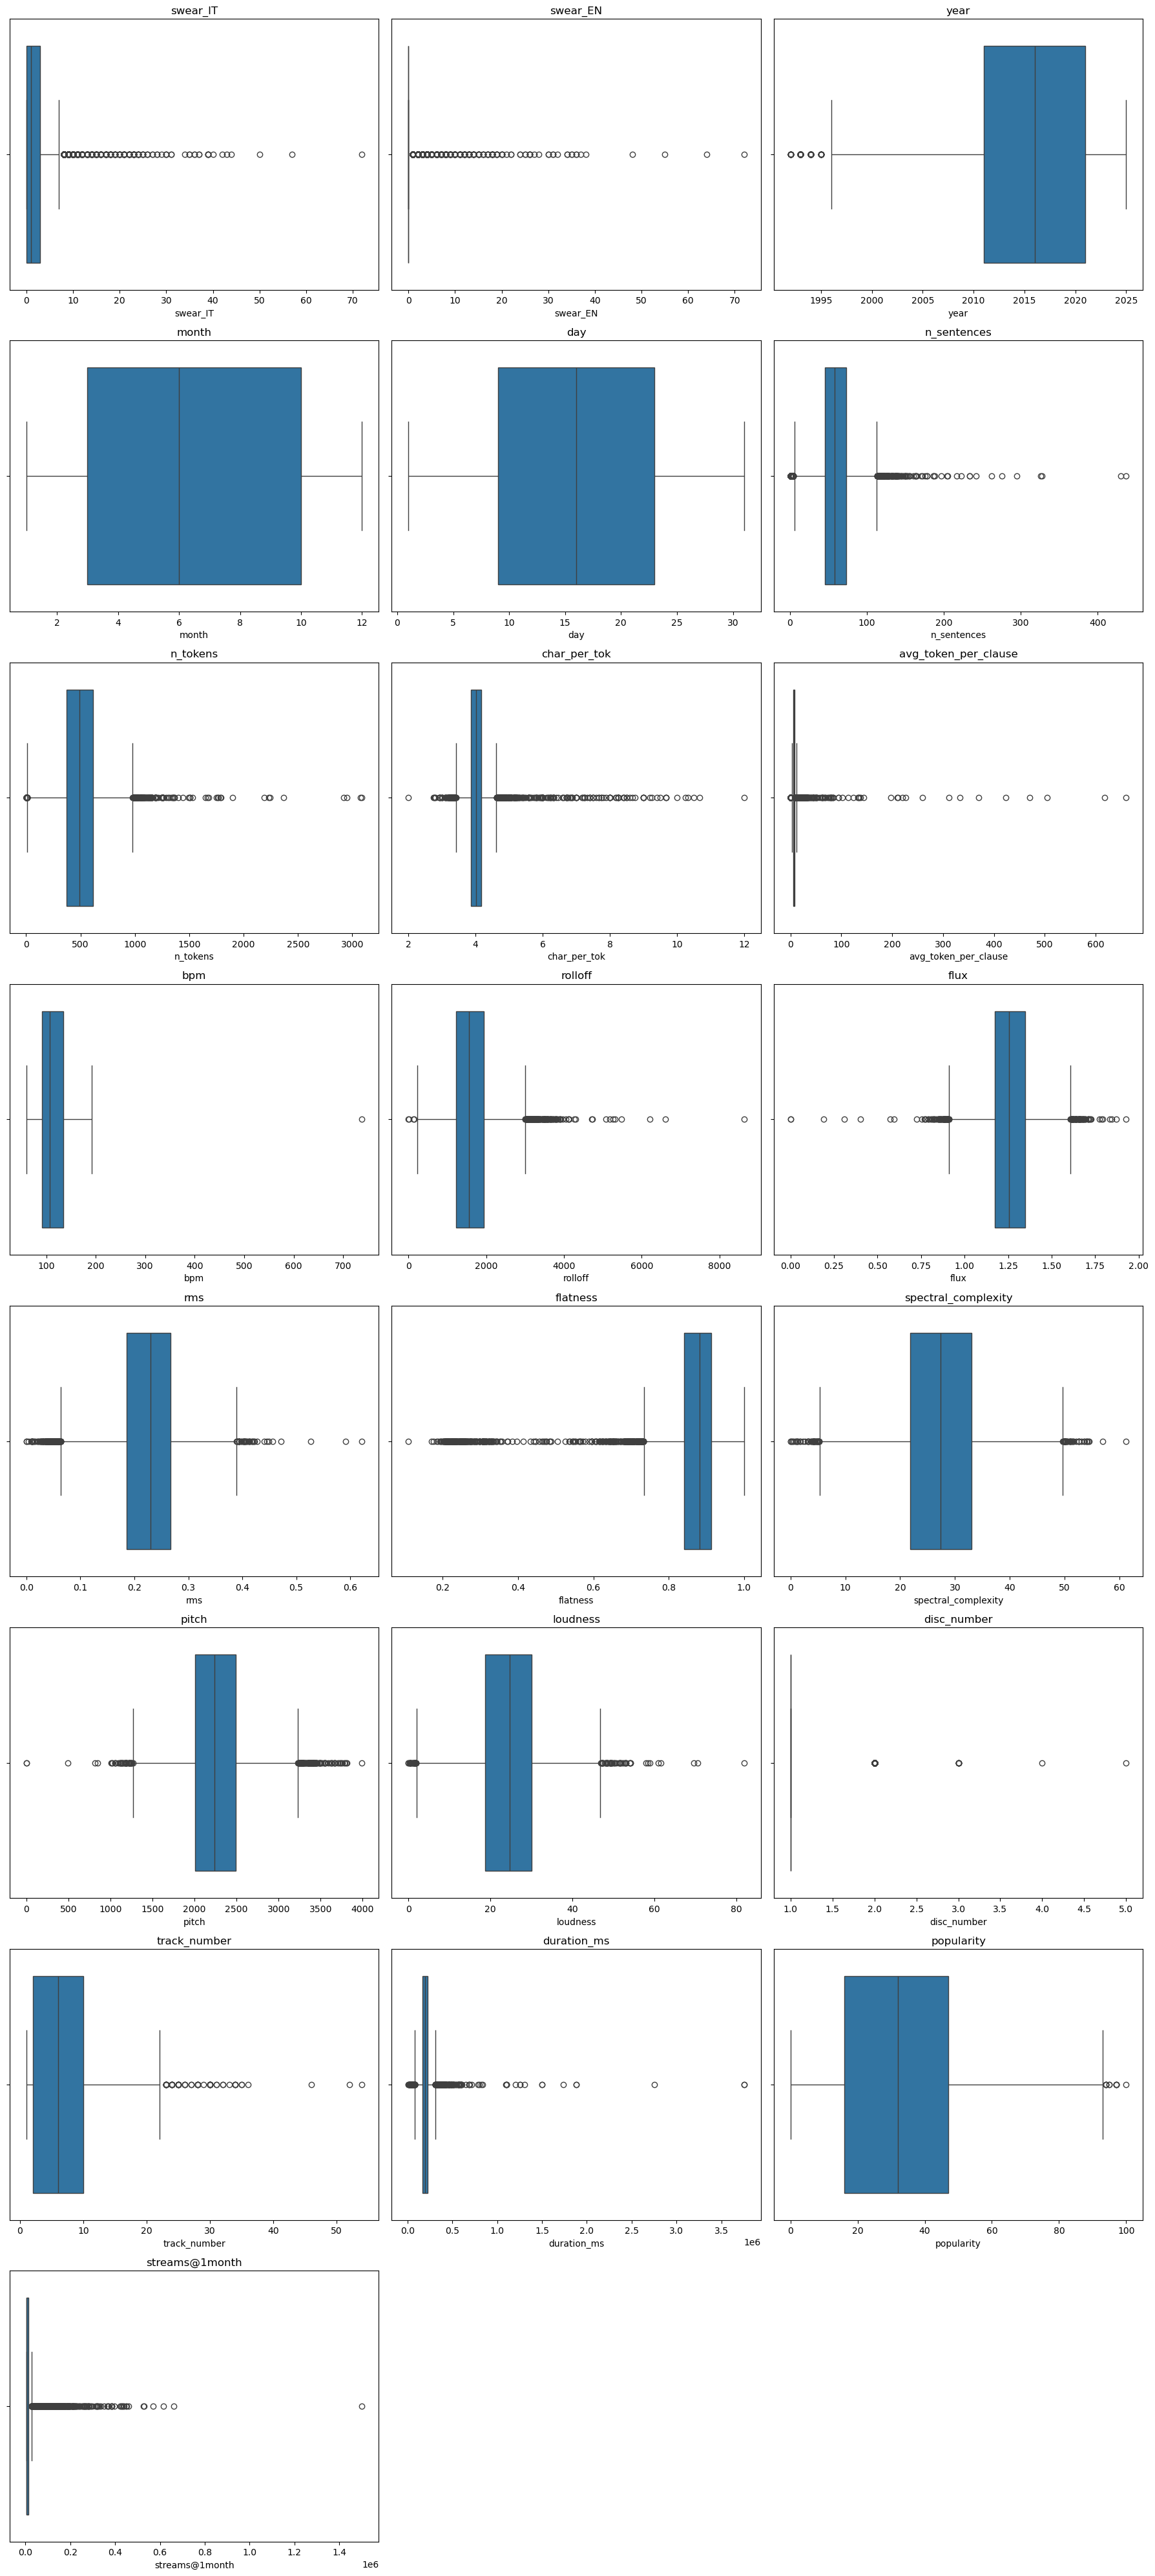

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns
numeric_cols = df_tracks.select_dtypes(include=['int64', 'float64']).columns

# Create a grid of subplots
n_cols = 3   # number of plots per row (you can change this)
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(18, 5 * n_rows))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=df_tracks[col])
    plt.title(col)

plt.tight_layout()
plt.show()


In [2]:
df_tracks.info()
df_tracks.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11166 entries, 0 to 11165
Data columns (total 37 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    11166 non-null  object 
 1   id_artist             11166 non-null  object 
 2   title                 11166 non-null  object 
 3   featured_artists      3517 non-null   object 
 4   primary_artist        11166 non-null  object 
 5   language              11061 non-null  object 
 6   album                 9652 non-null   object 
 7   swear_IT              11166 non-null  int64  
 8   swear_EN              11166 non-null  int64  
 9   swear_IT_words        11166 non-null  object 
 10  swear_EN_words        11166 non-null  object 
 11  year                  10722 non-null  float64
 12  month                 9969 non-null   float64
 13  day                   9843 non-null   float64
 14  n_sentences           11090 non-null  float64
 15  n_tokens           

,swear_IT,swear_EN,year,month,day,n_sentences,n_tokens,char_per_tok,avg_token_per_clause,bpm,...,rms,flatness,spectral_complexity,pitch,loudness,disc_number,track_number,duration_ms,popularity,streams@1month
count,11166.000000,11166.000000,10722.000000,9969.000000,9843.000000,11090.000000,11090.000000,11090.000000,11090.000000,11102.000000,...,11102.000000,11102.000000,11102.000000,11102.000000,11102.000000,11088.000000,11088.000000,1.108800e+04,11088.000000,1.116600e+04
mean,2.343006,0.711177,2015.135796,6.198515,15.808697,59.399639,496.891253,4.054416,8.002009,114.134841,...,0.223965,0.859986,27.410247,2256.028782,24.226955,1.016685,6.859127,2.035293e+05,32.656295,1.821737e+04
std,3.704831,2.555423,7.022598,3.482992,8.881989,24.711996,209.187612,0.445958,14.577876,26.827124,...,0.064592,0.109106,8.441590,382.134853,8.648780,0.138903,5.191472,8.825641e+04,19.781473,3.903201e+04
min,0.000000,0.000000,1992.000000,1.000000,1.000000,1.000000,3.000000,2.000000,0.000000,59.970000,...,0.000000,0.109400,0.000000,0.000000,0.000000,1.000000,1.000000,1.142600e+04,0.000000,4.011000e+03
25%,0.000000,0.000000,2011.000000,3.000000,9.000000,46.000000,372.000000,3.866946,5.859020,91.910000,...,0.186225,0.841400,21.881750,2003.341325,18.779500,1.000000,2.000000,1.701310e+05,16.000000,4.835000e+03
50%,1.000000,0.000000,2016.000000,6.000000,16.000000,58.000000,491.000000,4.012709,6.764171,106.975000,...,0.229700,0.882450,27.330850,2241.157450,24.666850,1.000000,6.000000,1.966725e+05,32.000000,5.644500e+03
75%,3.000000,0.000000,2021.000000,10.000000,23.000000,73.000000,615.000000,4.168686,8.090909,134.650000,...,0.267600,0.913075,32.978475,2493.492250,30.010175,1.000000,10.000000,2.271840e+05,47.000000,1.423925e+04
max,72.000000,72.000000,2025.000000,12.000000,31.000000,437.000000,3089.000000,12.000000,660.000000,738.270000,...,0.621900,1.000000,61.222500,3993.020300,81.947800,5.000000,54.000000,3.753057e+06,100.000000,1.501925e+06


In [8]:
df_artists.info()
df_artists.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id_author     104 non-null    object 
 1   name          104 non-null    object 
 2   gender        104 non-null    object 
 3   birth_date    73 non-null     object 
 4   birth_place   72 non-null     object 
 5   nationality   71 non-null     object 
 6   description   86 non-null     object 
 7   active_start  50 non-null     object 
 8   active_end    0 non-null      float64
 9   province      70 non-null     object 
 10  region        68 non-null     object 
 11  country       70 non-null     object 
 12  latitude      72 non-null     float64
 13  longitude     72 non-null     float64
dtypes: float64(3), object(11)
memory usage: 11.5+ KB


,active_end,latitude,longitude
count,0.0,72.000000,72.000000
mean,NaN,43.591374,11.060876
std,NaN,2.248674,2.591871
min,NaN,37.747452,7.525403
25%,NaN,41.577547,9.189635
50%,NaN,45.067755,9.917118
75%,NaN,45.464194,12.482932
max,NaN,45.806691,18.225226


In [9]:
print("Is the id a unique indentifier for the track (in df_track): ", df_tracks['id'].is_unique)
print("Is the id_author a unique indentifier for the artist (in df_artist): ", df_artists['id_author'].is_unique)

Is the id a unique indentifier for the track (in df_track):  False
Is the id_author a unique indentifier for the artist (in df_artist):  True


In [ ]:
print("There are: ",df_tracks.disc_number.value_counts())
print("\nThere are: ",df_tracks.album_type.value_counts())

there are:  disc_number
1.0    10915
2.0      164
3.0        7
5.0        1
4.0        1
Name: count, dtype: int64

there are:  album_type
album          9353
single         1544
compilation     191
Name: count, dtype: int64


In [16]:
df_tracks.select_dtypes(include=['object']).describe().T

,count,unique,top,freq
id,11166,11093,TR367132,4
id_artist,11166,104,ART91352277,353
title,11166,10521,Intro,36
featured_artists,3517,1740,Guè,64
primary_artist,11166,104,Mondo Marcio,353
language,11061,35,it,9352
album,9652,890,Rimo Da Quando,47
swear_IT_words,11166,2659,[],4176
swear_EN_words,11166,535,[],8426
album_name,11088,2421,SANTANA MONEY GANG,132


In [17]:
df_tracks.duplicated().sum()
#there are not duplicated row

np.int64(0)

In [ ]:
df_tracks[df_tracks.duplicated('id', keep=False)].sort_values(by='id')
#but the track id is not unique

In [19]:
missing_ids = set(df_tracks['id_artist']) - set(df_artists['id_author'])
print("The id_artist an the id_author in the two tables have the following different identifier", missing_ids)
# it's an empty set so it's the same
print("Is one a subset of the other?", set(df_tracks['id_artist']).issubset(set(df_artists['id_author'])))

# merged = df_tracks.merge(df_artists, left_on='id_artist', right_on='id_author', how='left')
# merged[merged['id_author'].isna()]

The id_artist an the id_author in the two tables have the following different identifier set()
Is one a subset of the other? True


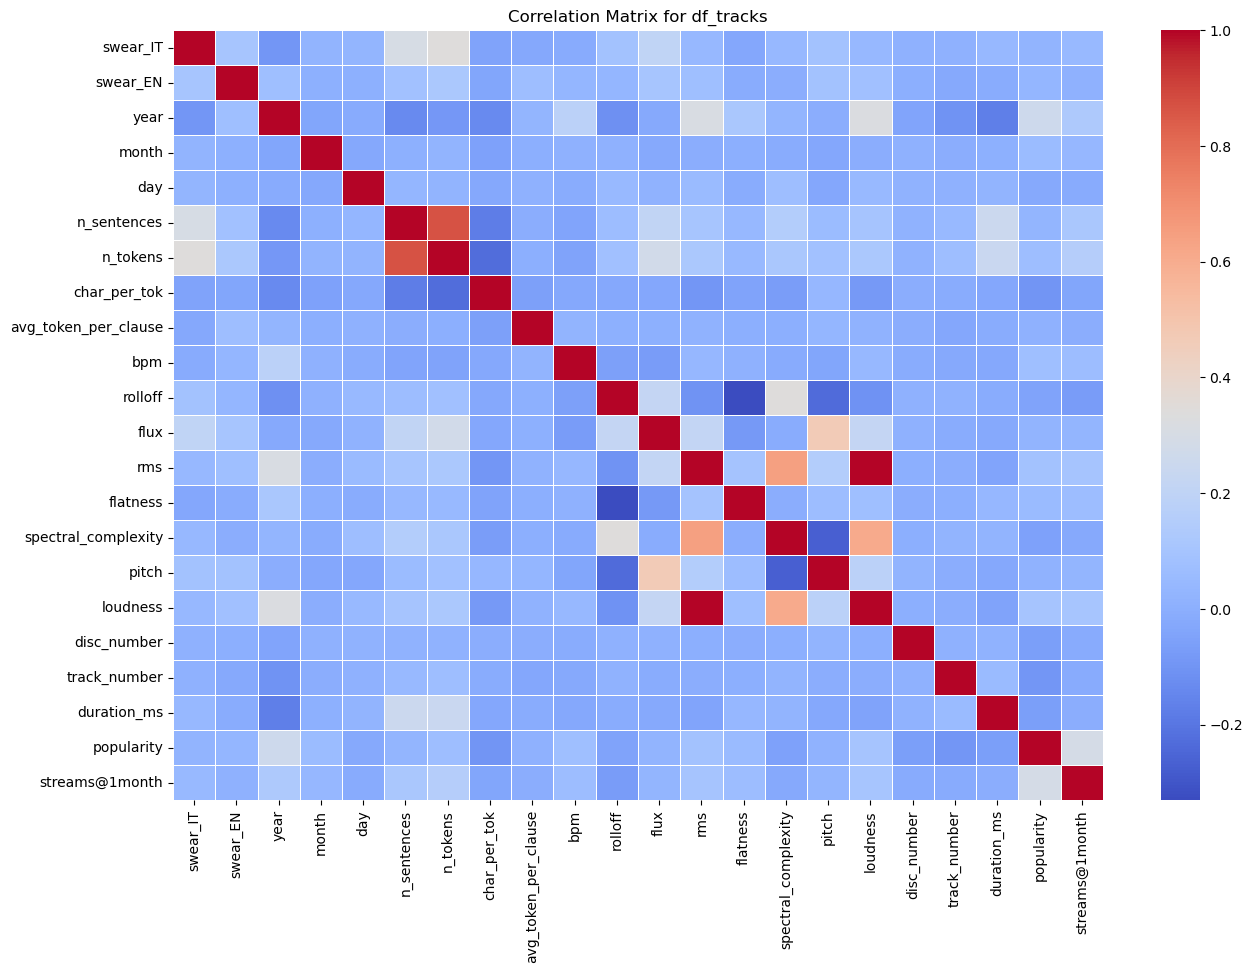

In [20]:
corr_matrix = df_tracks.corr(numeric_only=True)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, 
            annot=False,           
            cmap='coolwarm', 
            linewidths=0.5)
plt.title("Correlation Matrix for df_tracks")
plt.show()

In [21]:
def missing_values(data : pd.DataFrame, threshold : float = 10):

    na_count = data.isna().sum()
    na_exist = na_count[na_count > 0]
    na_abs_frq = na_exist.values
    na_rel_frq = round(na_exist/len(data)*100)
    missings = pd.DataFrame({'Nº of missings': na_abs_frq, '% of missings': na_rel_frq})
    missings = missings.sort_values(by = 'Nº of missings', ascending = False)

    if threshold:
        missings['Above threshold'] = [True if x > threshold else False for x in missings['% of missings']]
    
    return missings

missing_values(df_tracks)

,Nº of missings,% of missings,Above threshold
featured_artists,7649,69.0,True
album,1514,14.0,True
day,1323,12.0,True
month,1197,11.0,True
year,444,4.0,False
language,105,1.0,False
track_number,78,1.0,False
duration_ms,78,1.0,False
explicit,78,1.0,False
popularity,78,1.0,False


In [26]:
print("The columns without missing values are: \n", df_tracks.isnull().sum()[df_tracks.isnull().sum() == 0])

The columns without missing values are: 
 id                0
id_artist         0
title             0
primary_artist    0
swear_IT          0
swear_EN          0
swear_IT_words    0
swear_EN_words    0
streams@1month    0
dtype: int64


In [35]:
print("swear_IT is:", df_tracks["swear_IT"].dtypes)
print("swear_EN is:", df_tracks["swear_EN"].dtypes)

swear_IT is: int64
swear_EN is: int64


In [36]:
df_tracks["swear_IT_words"].unique

<bound method Series.unique of 0        ['cazzo', 'cesso', 'coglioni', 'figa', 'merda'...
1        ['cazzo', 'culo', 'frocio', 'puttana', 'sega',...
2          ['bastardo', 'cazzo', 'culo', 'merda', 'troia']
3        ['cazzo', 'culo', 'fottere', 'merda', 'pompino...
4                                                ['cazzo']
                               ...                        
11161                                                   []
11162                                          ['fortuna']
11163                                                   []
11164                                                   []
11165                                                   []
Name: swear_IT_words, Length: 11166, dtype: object>

In [37]:
df_tracks["swear_EN_words"].unique

<bound method Series.unique of 0                     ['bitch', 'fuck', 'porno', 'pussy']
1              ['escort', 'negro', 'sex', 'sexy', 'shit']
2        ['bastardo', 'bitch', 'bitches', 'cock', 'fuck']
3                               ['fuck', 'porno', 'shit']
4                                                      []
                               ...                       
11161                                                  []
11162                                                  []
11163                                                  []
11164                                           ['porno']
11165                                                  []
Name: swear_EN_words, Length: 11166, dtype: object>

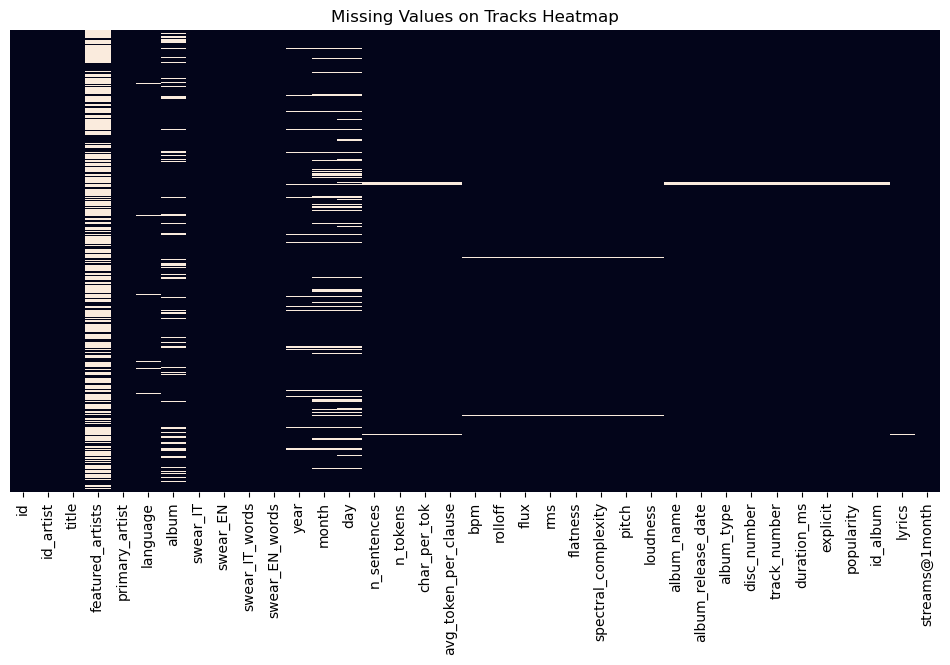

In [5]:
plt.figure(figsize=(12, 6))
sns.heatmap(df_tracks.isnull(), cbar=False, yticklabels=False)
plt.title("Missing Values on Tracks Heatmap")
plt.show()

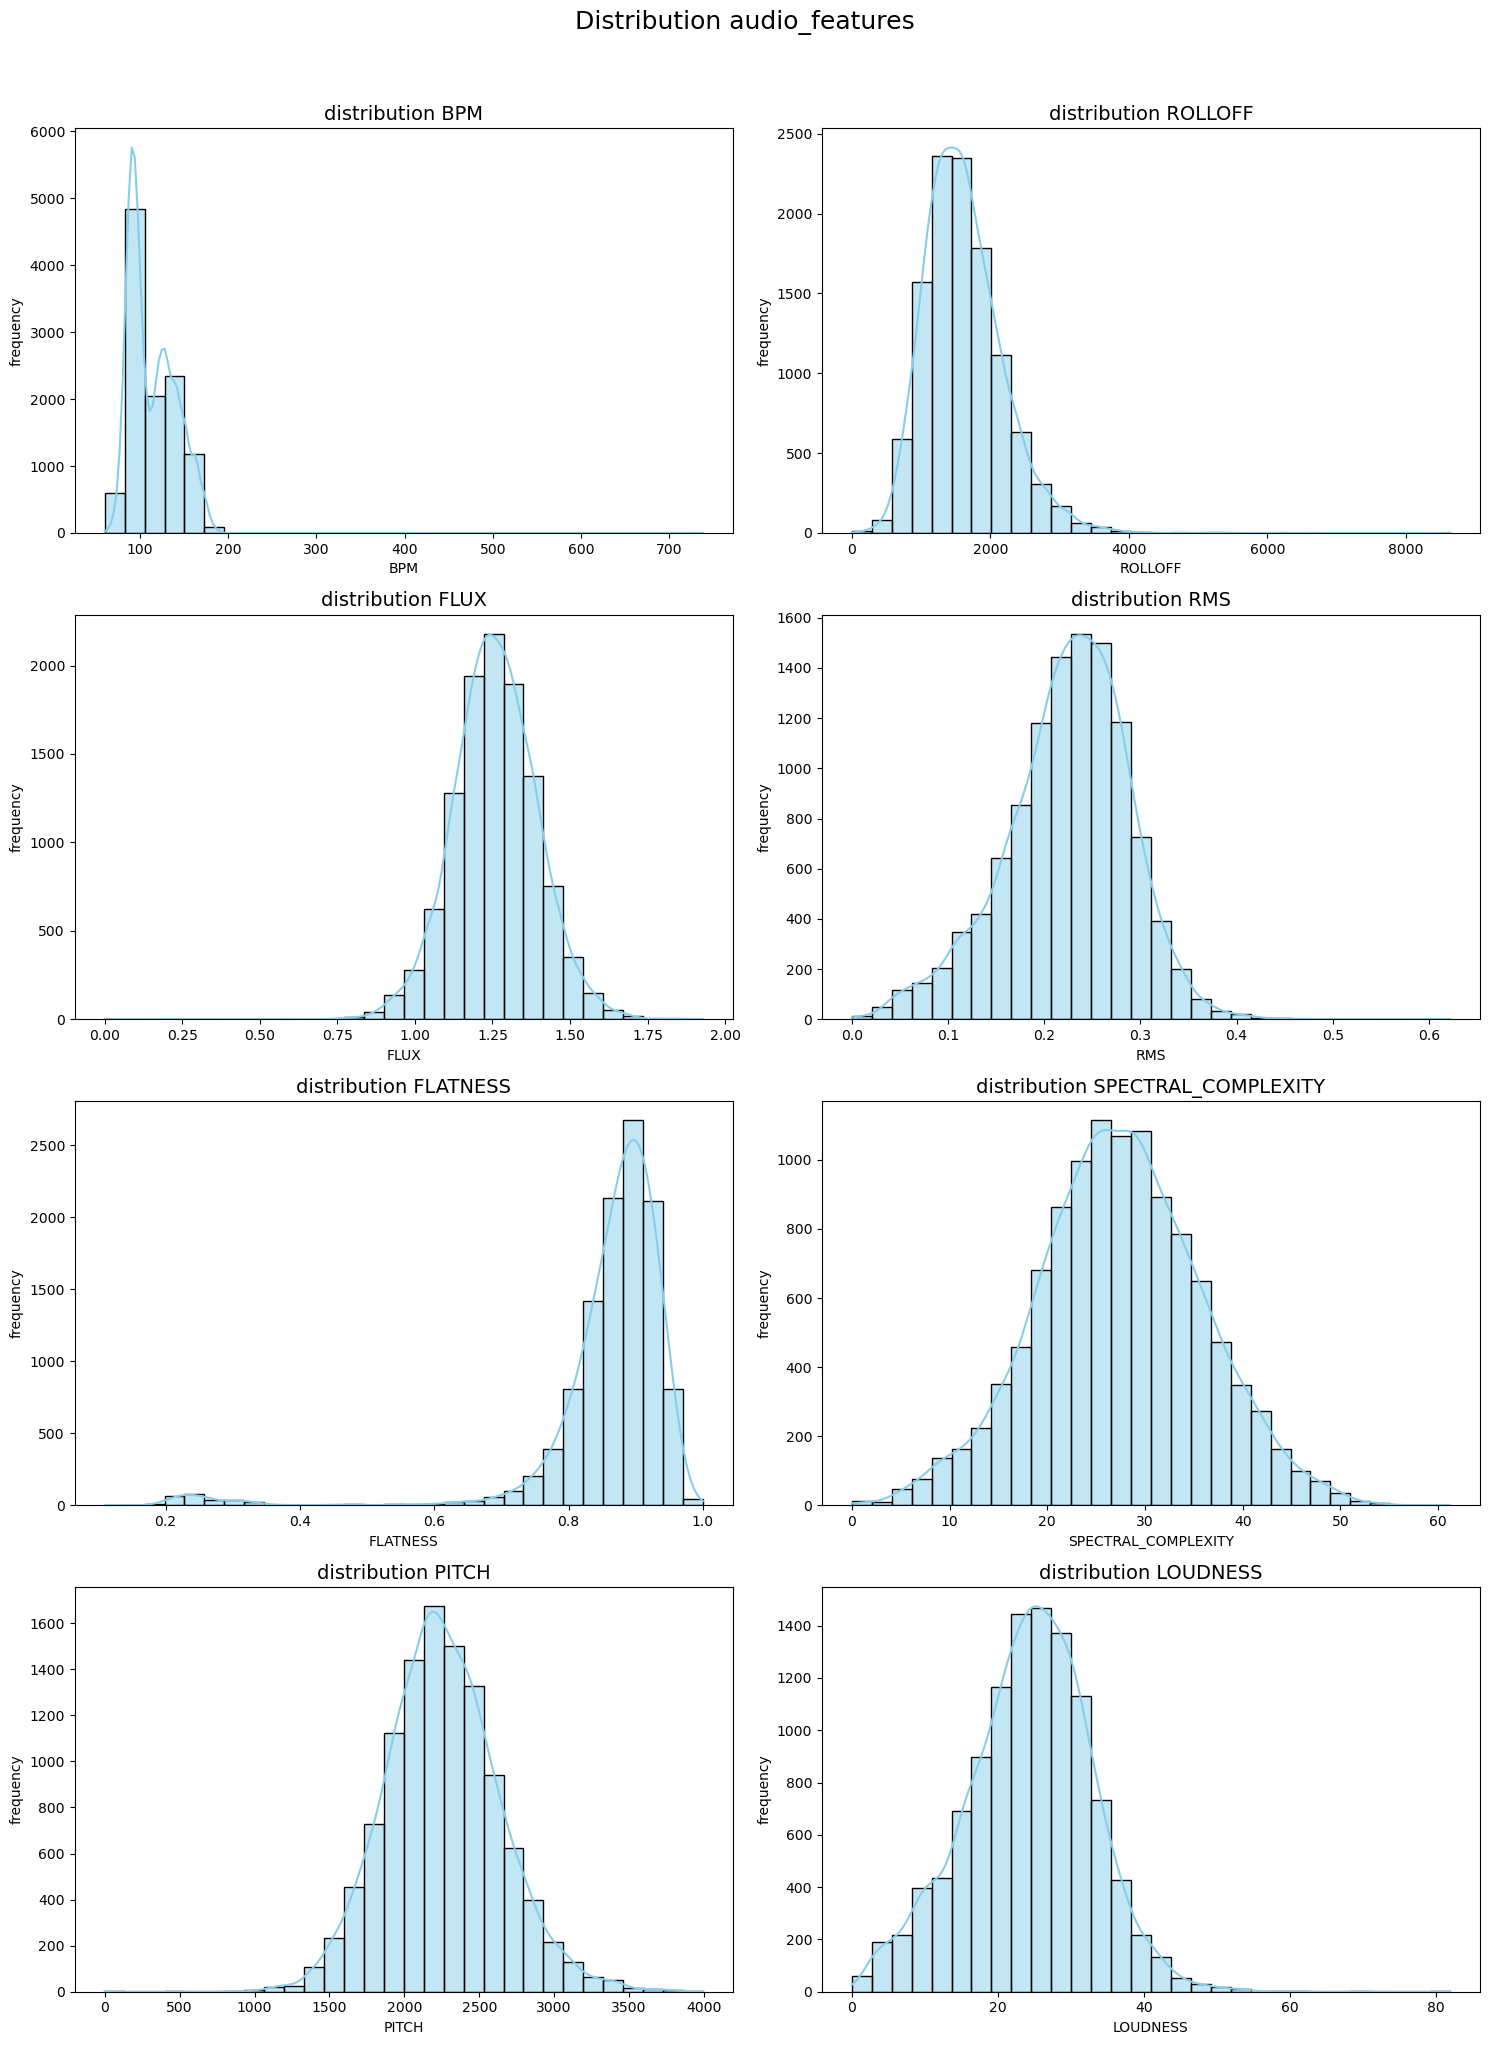

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

# columns to visualize
audio_features = ['bpm', 'rolloff', 'flux', 'rms', 'flatness', 'spectral_complexity', 'pitch', 'loudness']

# Configurate subplots
fig, axes = plt.subplots(4, 2, figsize=(15, 20))
axes = axes.flatten() # easily iterate over 1D array

# title for the entire figure
fig.suptitle('Distribution audio_features', fontsize=18, y=1.02)

# Iterate over each feature and plot the histogram
for i, feature in enumerate(audio_features):
    sns.histplot(df_tracks[feature], kde=True, ax=axes[i], color='skyblue', edgecolor='black', bins=30)
    
    # Title for each subplot
    axes[i].set_title(f'distribution {feature.upper()}', fontsize=14)
    axes[i].set_xlabel(feature.upper())
    axes[i].set_ylabel('frequency')
    
plt.tight_layout()
plt.show()

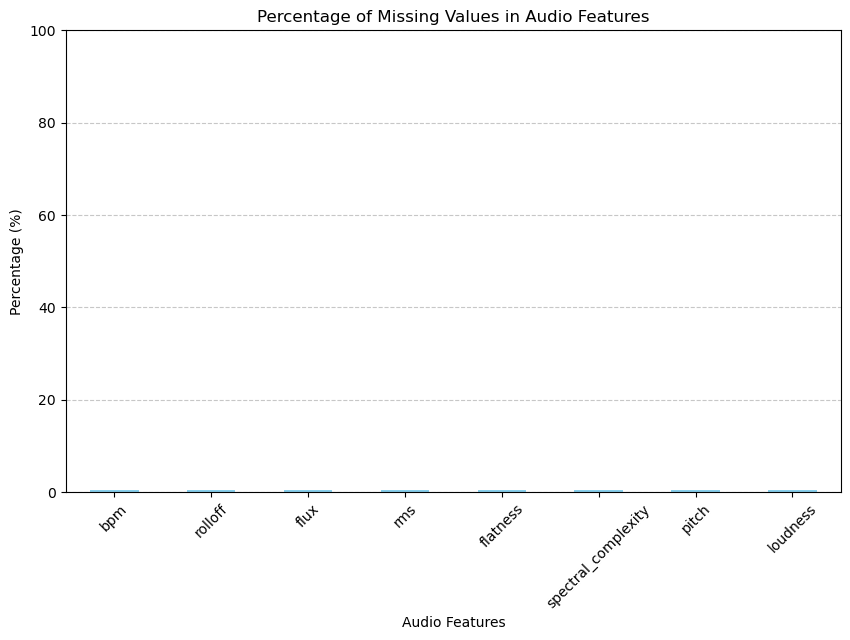

In [42]:
# List of audio feature columns
audio_features = ['bpm', 'rolloff', 'flux', 'rms', 'flatness', 'spectral_complexity', 'pitch', 'loudness']

# Calculate percentage of missing values
missing_percent = df_tracks[audio_features].isna().mean() * 100

# Plot
plt.figure(figsize=(10,6))
missing_percent.plot(kind='bar', color='skyblue')
plt.title('Percentage of Missing Values in Audio Features')
plt.ylabel('Percentage (%)')
plt.xlabel('Audio Features')
plt.ylim(0, 100)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [24]:
df_tracks['language'].unique()

array(['pl', 'en', 'it', 'fr', nan, 'eu', 'sco', 'co', 'da', 'nl', 'et',
       'pt', 'es', 'war', 'lt', 'ia', 'de', 'cs', 'gl', 'sr', 'rw', 'ca',
       'ro', 'no', 'aa', 'chr', 'rm', 'ru', 'mt', 'qu', 'cy', 'eo', 'bg',
       'la', 'sq', 'sw'], dtype=object)

In [40]:
#we check if it is a list or a string
print("what is it?", df_tracks['swear_IT_words'].iloc[0])
print("what is it?", df_tracks['swear_EN_words'].iloc[0])

what is it? ['cazzo', 'cesso', 'coglioni', 'figa', 'merda', 'palle', 'piscio', 'porca', 'stronzo']
what is it? ['bitch', 'fuck', 'porno', 'pussy']


In [ ]:
#Some text cleaning on the swear_EN_words and swear_IT_words columns:
# when we don't have any swear word the value is '[]' instead we consider no_swear

In [9]:
type(df_tracks['swear_IT_words'].iloc[0])

str

In [10]:
import ast

def clean_list_column(value):
    # Try to parse string into a real Python list
    try:
        parsed = ast.literal_eval(value)  # converts "['a','b']" → ['a','b']
    except:
        return "none"

    # If parsed value is a list
    if isinstance(parsed, list):
        if len(parsed) == 0:
            return "no_swear"
        return ", ".join(parsed)

    # Any unexpected case
    return "none"

df_tracks['swear_IT_words_clean'] = df_tracks['swear_IT_words'].apply(clean_list_column)
df_tracks['swear_EN_words_clean'] = df_tracks['swear_EN_words'].apply(clean_list_column)


In [11]:
df_tracks[['swear_EN_words', 'swear_IT_words', 'swear_EN_words_clean', 'swear_IT_words_clean']]

,swear_EN_words,swear_IT_words,swear_EN_words_clean,swear_IT_words_clean
0,"['bitch', 'fuck', 'porno', 'pussy']","['cazzo', 'cesso', 'coglioni', 'figa', 'merda'...","bitch, fuck, porno, pussy","cazzo, cesso, coglioni, figa, merda, palle, pi..."
1,"['escort', 'negro', 'sex', 'sexy', 'shit']","['cazzo', 'culo', 'frocio', 'puttana', 'sega',...","escort, negro, sex, sexy, shit","cazzo, culo, frocio, puttana, sega, troia"
2,"['bastardo', 'bitch', 'bitches', 'cock', 'fuck']","['bastardo', 'cazzo', 'culo', 'merda', 'troia']","bastardo, bitch, bitches, cock, fuck","bastardo, cazzo, culo, merda, troia"
3,"['fuck', 'porno', 'shit']","['cazzo', 'culo', 'fottere', 'merda', 'pompino...","fuck, porno, shit","cazzo, culo, fottere, merda, pompino, sega, troia"
4,[],['cazzo'],no_swear,cazzo
...,...,...,...,...
11161,[],[],no_swear,no_swear
11162,[],['fortuna'],no_swear,fortuna
11163,[],[],no_swear,no_swear
11164,['porno'],[],porno,no_swear


In [13]:
#we remove the original columns:
df_tracks.drop(columns=['swear_IT_words', 'swear_EN_words'], inplace=True)

In [15]:
df_tracks["lyrics"].head()

0    Oplà, ah\r\nBdope, chiama due b—\r\n\r\nMi can...
1    Greg Willen, non dormire\r\n(Brr-poh)\r\n\r\nT...
2    Mothz\r\nYeah, yeah, yeah-yeah\r\nBdope, chiam...
3    Designer sui vestiti penso di essere un outlet...
4    Bdope (Yeah)\r\n\r\nVuole solo me, non fare la...
Name: lyrics, dtype: object

In [ ]:
import re
#first raw cleaning on the lyrics column
def clean_lyrics_basic(text):
    if pd.isna(text):
        return ""
    text = text.replace("\r", " ").replace("\n", " ")
    text = re.sub(r"\s+", " ", text).strip()
    return text

df_tracks["lyrics_clean"] = df_tracks["lyrics"].apply(clean_lyrics_basic)
df_tracks["lyrics_clean"].head()

0    Oplà, ah Bdope, chiama due b— Mi candiderei co...
1    Greg Willen, non dormire (Brr-poh) T-T-Troppi ...
2    Mothz Yeah, yeah, yeah-yeah Bdope, chiama due ...
3    Designer sui vestiti penso di essere un outlet...
4    Bdope (Yeah) Vuole solo me, non fare la gelosa...
Name: lyrics_clean, dtype: object

In [18]:
df_tracks.drop(columns=['lyrics'], inplace=True)

In [19]:
df_tracks.columns

Index(['id', 'id_artist', 'title', 'featured_artists', 'primary_artist',
       'language', 'album', 'swear_IT', 'swear_EN', 'year', 'month', 'day',
       'n_sentences', 'n_tokens', 'char_per_tok', 'avg_token_per_clause',
       'bpm', 'rolloff', 'flux', 'rms', 'flatness', 'spectral_complexity',
       'pitch', 'loudness', 'album_name', 'album_release_date', 'album_type',
       'disc_number', 'track_number', 'duration_ms', 'explicit', 'popularity',
       'id_album', 'streams@1month', 'swear_IT_words_clean',
       'swear_EN_words_clean', 'lyrics_clean'],
      dtype='object')

In [41]:
df_tracks[df_tracks['lyrics_clean'] == ""]

,id,id_artist,title,featured_artists,primary_artist,language,album,swear_IT,swear_EN,year,...,disc_number,track_number,duration_ms,explicit,popularity,id_album,streams@1month,swear_IT_words_clean,swear_EN_words_clean,lyrics_clean
6950,TR105319,ART46711784,Consegnato.02,NaN,Frah Quintale,it,NaN,0,0,2017.0,...,1.0,1.0,155946.0,True,0.0,ALB903727,5519.0,no_swear,no_swear,
6952,TR252811,ART46711784,Consegnato.01,NaN,Frah Quintale,it,NaN,0,0,2017.0,...,1.0,21.0,92125.0,False,25.0,ALB635494,4906.0,no_swear,no_swear,
9775,TR590611,ART48622722,Introliberassociazione,NaN,Salmo,it,Sotto Pelle,0,0,2004.0,...,1.0,13.0,205266.0,True,60.0,ALB370362,4944.0,no_swear,no_swear,


In [ ]:
# # Esporta
# df_tracks.to_csv("track_after_assigment1.csv", index=False)

# print("File created: track_after_assigment1.csv")

File created: track_after_assigment1.csv


In [ ]:
#Now some artist analysis

In [ ]:
print("how many countrys are represented in the dataset?\n", df_artists.country.value_counts())

how many countrys are represented in the dataset?
 country
Italia    70
Name: count, dtype: int64


In [24]:
def missing_values(data : pd.DataFrame, threshold : float = 10):

    na_count = data.isna().sum()
    na_exist = na_count[na_count > 0]
    na_abs_frq = na_exist.values
    na_rel_frq = round(na_exist/len(data)*100)
    missings = pd.DataFrame({'Nº of missings': na_abs_frq, '% of missings': na_rel_frq})
    missings = missings.sort_values(by = 'Nº of missings', ascending = False)

    if threshold:
        missings['Above threshold'] = [True if x > threshold else False for x in missings['% of missings']]
    
    return missings

missing_values(df_artists)

,Nº of missings,% of missings,Above threshold
active_end,104,100.0,True
active_start,54,52.0,True
region,36,35.0,True
country,34,33.0,True
province,34,33.0,True
nationality,33,32.0,True
birth_place,32,31.0,True
longitude,32,31.0,True
latitude,32,31.0,True
birth_date,31,30.0,True


In [25]:
print("The columns without missing values are: \n", df_artists.isnull().sum()[df_artists.isnull().sum() == 0])

The columns without missing values are: 
 id_author    0
name         0
gender       0
dtype: int64


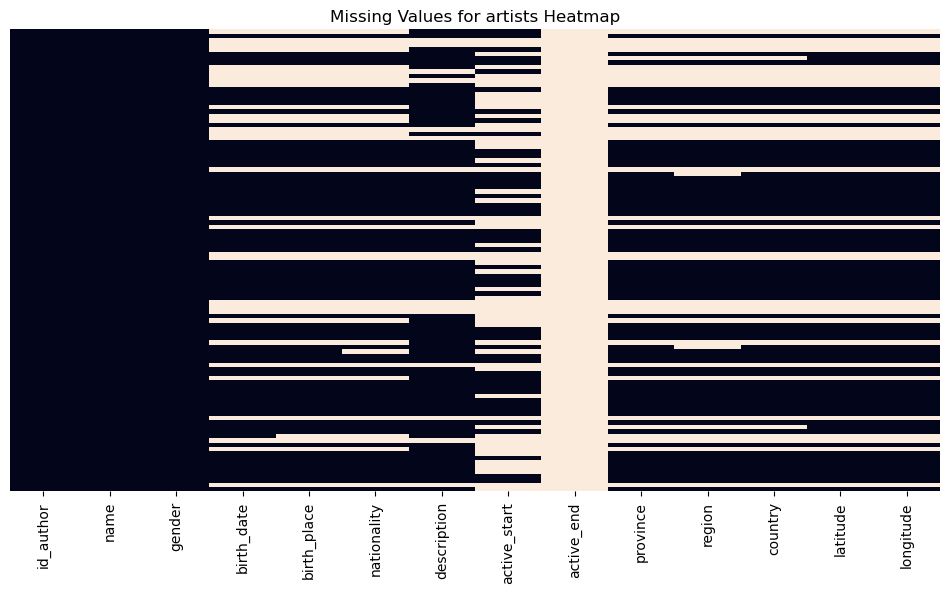

In [26]:
plt.figure(figsize=(12, 6))
sns.heatmap(df_artists.isnull(), cbar=False, yticklabels=False)
plt.title("Missing Values for artists Heatmap")
plt.show()

In [27]:
df_artists.duplicated().any()

np.False_

In [ ]:
# df_artists.drop(columns=['active_end'], inplace=True)

In [28]:
has_coords = df_artists["latitude"].notna() & df_artists["longitude"].notna()

missing_location = (
    df_artists["province"].isna() | (df_artists["province"] == "") |
    df_artists["region"].isna()   | (df_artists["region"] == "") |
    df_artists["country"].isna()  | (df_artists["country"] == "")
)

result = df_artists[has_coords & missing_location]

print("Mising location but have lat/long:", len(result))

Mising location but have lat/long: 4


In [49]:
import requests
import time

def infer_location(lat, lon):
    url = "https://api.bigdatacloud.net/data/reverse-geocode-client"
    params = {
        "latitude": lat,
        "longitude": lon,
        "localityLanguage": "en"
    }

    try:
        response = requests.get(url, params=params, timeout=10)
        data = response.json()

        province = data.get("principalSubdivision")    
        country  = data.get("countryName")            

        region_info = data.get("localityInfo", {}).get("administrative", [])
        region = None
        if len(region_info) > 1:
            region = region_info[1].get("name")

        return province, region, country

    except Exception as e:
        print(f"Error for {lat},{lon}: {e}")
        return None, None, None
    

In [50]:
for idx, row in df_artists.iterrows():

    lat = row["latitude"]
    lon = row["longitude"]

    if pd.isna(lat) or pd.isna(lon):
        continue

    missing_province = pd.isna(row["province"]) or row["province"] == ""
    missing_region   = pd.isna(row["region"])   or row["region"] == ""
    missing_country  = pd.isna(row["country"])  or row["country"] == ""

    if missing_province or missing_region or missing_country:

        province, region, country = infer_location(lat, lon)

        if missing_province and province:
            df_artists.at[idx, "province"] = province

        if missing_region and region:
            df_artists.at[idx, "region"] = region

        if missing_country and country:
            df_artists.at[idx, "country"] = country

        print(f"Row {idx} → {province}, {region}, {country}")
        time.sleep(0.2)

Row 6 → Piemonte, Northwest Italy, Italy
Row 29 → Marche, Central Italy, Italy
Row 66 → Marche, Central Italy, Italy
Row 84 → Emilia-Romagna, Northeast Italy, Italy


In [43]:
#infer nationality from description
rows = df_artists.values.tolist()

keyword_map = {
    "italiano": "Italia",
    "italiana": "Italia",
    "italiani": "Italia",
    "canadese": "Canadian",
    "francese": "French",
    "inglese": "British",
    "americano": "American",
    "americana": "American",
    "indiano": "Indian"
}

def infer_nationality_from_row(row):
    if pd.notna(row['nationality']) and str(row['nationality']).strip():
        return row['nationality']
    desc = row['description']
    if not isinstance(desc, str):
        return row['nationality']
    desc = desc.lower()
    for kw, nat in keyword_map.items():
        if kw in desc:
            return nat
    return row['nationality']

df_artists['nationality'] = df_artists.apply(infer_nationality_from_row, axis=1)

print("Missing nationality now:", df_artists['nationality'].isna().sum())

Missing nationality now: 23


In [45]:
df_artists[(df_artists['nationality'].isna()) & (df_artists['description'].notna())]

,id_author,name,gender,birth_date,birth_place,nationality,description,active_start,active_end,province,region,country,latitude,longitude
8,ART19605256,beba,F,NaN,NaN,NaN,cognome,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10,ART03111237,brusco,M,NaN,NaN,NaN,cognome,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12,ART28846313,caneda,M,NaN,NaN,NaN,cognome,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65,ART66452136,mistico,M,NaN,NaN,NaN,tipo di barca a vela usata nel XVIII e XIX secolo,NaN,NaN,NaN,NaN,NaN,NaN,NaN
70,ART62385172,nerone,M,NaN,NaN,NaN,opera lirica di Pietro Mascagni,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [46]:
#we remove non artist from the dataset based on description field
non_artist_keywords = [
    "cognome",                         # surname
    "tipo di barca",                   # boat type
    "tipo di barca a vela",            # sailing boat
    "opera lirica",                    # opera (not an artist)
]

def is_non_artist(desc):
    if not isinstance(desc, str):
        return False
    desc_lower = desc.lower()
    return any(keyword in desc_lower for keyword in non_artist_keywords)

mask_non_artist = df_artists["description"].apply(is_non_artist)

df_artists = df_artists[~mask_non_artist].reset_index(drop=True)

In [ ]:
#FROM HERE IT DOESNT WORK, PLEASE CHECK

In [59]:
#try to get birth_dat,birth_place,active_start,active_end,latitude,longtitude informations
import requests
import time
import pandas as pd

# --- Cache to avoid repeated queries ---
CACHE = {
    "musicbrainz": {}
}

# --- Helper functions ---
def is_missing(x):
    return x is None or x == "" or (isinstance(x, float) and pd.isna(x))

def safe_request(url, params=None, headers=None, retries=3, delay=1):
    for i in range(retries):
        try:
            r = requests.get(url, params=params, headers=headers, timeout=10)
            r.raise_for_status()
            return r
        except Exception as e:
            print(f"Request failed ({i+1}/{retries}) for URL {url}: {e}")
            time.sleep(delay)
    return None

def search_musicbrainz(name):
    """
    Search MusicBrainz for an artist and return enriched data.
    """
    name = name.strip()
    if not name:
        return None

    if name in CACHE["musicbrainz"]:
        return CACHE["musicbrainz"][name]

    url = "https://musicbrainz.org/ws/2/artist/"
    params = {"query": name, "fmt": "json", "limit": 1}
    headers = {"User-Agent": "MyApp/1.0 (email@example.com)"}

    r = safe_request(url, params=params, headers=headers)
    if r is None:
        CACHE["musicbrainz"][name] = None
        return None

    data = r.json()
    if "artists" not in data or len(data["artists"]) == 0:
        CACHE["musicbrainz"][name] = None
        return None

    artist = data["artists"][0]

    result = {
        "birth_date": artist.get("life-span", {}).get("begin"),
        "active_start": artist.get("life-span", {}).get("begin"),
        "active_end": artist.get("life-span", {}).get("end"),
        "country": artist.get("area", {}).get("name"),
        "disambiguation": artist.get("disambiguation", None)
    }

    CACHE["musicbrainz"][name] = result
    return result

def fill_from_musicbrainz(df, delay=1.5):
    """
    Fill missing artist data in df using MusicBrainz.
    Automatically logs which rows are updated.
    """
    print("\nMusicBrainz enrichment started...\n")

    filled = []
    failed = []

    for idx, row in df.iterrows():
        need_birth  = is_missing(row.get("birth_date"))
        need_country = is_missing(row.get("country"))

        if not (need_birth or need_country):
            continue

        artist_name = row.get("name")
        info = search_musicbrainz(artist_name)
        time.sleep(delay)  # Respect MusicBrainz rate limits

        if not info:
            failed.append(artist_name)
            continue

        updated_fields = {}
        if need_birth and info.get("birth_date"):
            df.at[idx, "birth_date"] = info["birth_date"]
            updated_fields["birth_date"] = info["birth_date"]

        if need_country and info.get("country"):
            df.at[idx, "country"] = info["country"]
            updated_fields["country"] = info["country"]

        if updated_fields:
            filled.append((idx, artist_name, updated_fields))

    print(f"\nEnrichment complete. Filled {len(filled)} rows.")
    if failed:
        print(f"Failed to fetch data for {len(failed)} artists:\n", failed[:10], "..." if len(failed)>10 else "")

    # Optional: show filled rows in detail
    for idx, name, updates in filled:
        print(f"Row {idx} | {name}")
        for col, val in updates.items():
            print(f"  → Filled {col}: {val}")
        print()

    return df


In [61]:
# filter only the missing values
missing_df = df_artists[
    df_artists['birth_date'].isna() |
    df_artists['birth_place'].isna() |
    df_artists['active_start'].isna() |
    df_artists['country'].isna()
]

# apply enrichment only on those
filled_df = fill_from_musicbrainz(missing_df)

# update original df
df_artists.update(filled_df)

# check missing
print(df_artists[['birth_date', 'birth_place', 'active_start', 'country']].isna().sum())




MusicBrainz enrichment started...

Request failed (1/3) for URL https://musicbrainz.org/ws/2/artist/: HTTPSConnectionPool(host='musicbrainz.org', port=443): Max retries exceeded with url: /ws/2/artist/?query=dargen+d_amico&fmt=json&limit=1 (Caused by SSLError(SSLEOFError(8, '[SSL: UNEXPECTED_EOF_WHILE_READING] EOF occurred in violation of protocol (_ssl.c:1028)')))
Request failed (2/3) for URL https://musicbrainz.org/ws/2/artist/: HTTPSConnectionPool(host='musicbrainz.org', port=443): Max retries exceeded with url: /ws/2/artist/?query=dargen+d_amico&fmt=json&limit=1 (Caused by SSLError(SSLEOFError(8, '[SSL: UNEXPECTED_EOF_WHILE_READING] EOF occurred in violation of protocol (_ssl.c:1028)')))
Request failed (3/3) for URL https://musicbrainz.org/ws/2/artist/: HTTPSConnectionPool(host='musicbrainz.org', port=443): Max retries exceeded with url: /ws/2/artist/?query=dargen+d_amico&fmt=json&limit=1 (Caused by SSLError(SSLEOFError(8, '[SSL: UNEXPECTED_EOF_WHILE_READING] EOF occurred in viola

KeyboardInterrupt: 

In [56]:
df_artists.isnull().sum()

id_author        0
name             0
gender           0
birth_date      25
birth_place     27
nationality     18
description     18
active_start    49
active_end      99
province        27
region          27
country         26
latitude        27
longitude       27
dtype: int64